# Module 5 — Cluster Hypothesis Testing

Testing the hypothesis: *"The model has a shared set of neurons dedicated to iteration & streaming — moving through a sequence one item at a time."*

## Hypothesis

**Iteration & Streaming Cluster:**
- AST nodes: `For, While, ListComp, DictComp, SetComp, GeneratorExp, Yield, YieldFrom, Break, Continue`
- Builtins: `map, filter, zip, enumerate, range, iter, next, reversed`

**Sub-cluster expectation:** `Yield`, `YieldFrom`, `GeneratorExp` may branch off into a specialized "lazy evaluation" sub-circuit.

## Tests

1. **Intra- vs inter-cluster similarity** — Is the cluster more self-similar than random?
2. **Shared core extraction** — Progressive intersection to find stable "iteration neurons"
3. **Sub-cluster structure** — Do eager loops, comprehensions, and lazy generators form sub-groups?
4. **Core exclusivity** — Are core neurons dedicated to iteration or shared with everything?
5. **t-SNE projection** — 2D visualization colored by cluster membership
6. **Dendrogram** — Hierarchical clustering to reveal tree structure

In [1]:
# Cell 1 – Setup & load atlas
import subprocess, sys, os, shutil
for pkg in ["h5py", "seaborn", "matplotlib", "numpy", "pandas", "tqdm", "scipy", "scikit-learn"]:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

# ── Detect environment ───────────────────────────────────────────────────
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    mp = "/content/drive"
    subprocess.run(["fusermount", "-uz", mp], capture_output=True)
    if os.path.isdir(mp):
        shutil.rmtree(mp, ignore_errors=True)
    drive.mount(mp)

# ── Dataset selector ─────────────────────────────────────────────────────
DATASET = "115_epsilon_005"    # "test" or "small"

_DATASETS = {
    "115_strong":  "universal_115x100_strong",
    "115_medium":  "universal_115x100_medium",
    "115_epsilon_005":    "universal_115x100_epsilon_005",
}



_base = _DATASETS[DATASET]

if IN_COLAB:
    DATA_DIR = "/content/drive/MyDrive/DATA/CSP-Atlas"
else:
    DATA_DIR = "/Users/piotrwilam/Data/CSP-Atlas"

ATLAS_HDF5 = f"{DATA_DIR}/{_base}.h5"

# ── Imports ──────────────────────────────────────────────────────────────
LOCAL_SRC = "/Users/piotrwilam/Code/CSP-Atlas/src"
COLAB_SRC = "/content/drive/MyDrive/CODE/CSP-Atlas/src"
SRC_PATH  = LOCAL_SRC if os.path.isdir(LOCAL_SRC) else COLAB_SRC
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, h5py
from module2.io_utils import load_atlas_hdf5

# ── Load atlas ───────────────────────────────────────────────────────────
print(f"Environment : {'Colab' if IN_COLAB else 'Local'}")
print(f"Loading     : {ATLAS_HDF5}")
atlas = load_atlas_hdf5(ATLAS_HDF5)
pair_masks       = atlas["pair_masks"]
universal_masks  = atlas["universal_masks"]
metrics          = atlas["metrics"]
metadata         = atlas["metadata"]

print(f"Pairs       : {len(pair_masks)}")
print(f"AST nodes   : {len(universal_masks['ast'])}")
print(f"Builtins    : {len(universal_masks['builtin'])}")

Environment : Local
Loading     : /Users/piotrwilam/Data/CSP-Atlas/universal_115x100_epsilon_005.h5
Pairs       : 1370
AST nodes   : 44
Builtins    : 71


In [2]:
# Cell 2 – Build Layer 5 selective neuron matrix + define hypothesis cluster
FOCUS_LAYER = 5

layer_ids = sorted({lid for lm in pair_masks.values() for lid in lm})
neurons_per_layer = None

# ── Build full mask matrix (circuits x all neurons across layers) ────────
circuit_names = []
mask_rows = []

for name in sorted(universal_masks["ast"]):
    vec = []
    for lid in layer_ids:
        m = universal_masks["ast"][name].get(lid)
        if m is not None:
            vec.append(m.astype(np.float32))
    if vec:
        circuit_names.append(f"AST:{name}")
        mask_rows.append(np.concatenate(vec))

for name in sorted(universal_masks["builtin"]):
    vec = []
    for lid in layer_ids:
        m = universal_masks["builtin"][name].get(lid)
        if m is not None:
            vec.append(m.astype(np.float32))
    if vec:
        circuit_names.append(f"BLT:{name}")
        mask_rows.append(np.concatenate(vec))

mask_matrix = np.array(mask_rows)
n_circuits, n_neurons = mask_matrix.shape
neurons_per_layer = n_neurons // len(layer_ids)

# ── Selective neurons (exclude dark + always-on) ─────────────────────────
col_sums = mask_matrix.sum(axis=0)
selective_cols = (col_sums > 0) & (col_sums < n_circuits)

# ── Extract Layer 5 selective neurons ────────────────────────────────────
layer_idx = layer_ids.index(FOCUS_LAYER)
s = layer_idx * neurons_per_layer
e = s + neurons_per_layer
layer_selective = selective_cols[s:e]
layer_sel_indices = np.where(layer_selective)[0]
n_sel_layer = len(layer_sel_indices)

layer_matrix = mask_matrix[:, s:e][:, layer_selective].astype(np.float32)

# ── Define hypothesis cluster ────────────────────────────────────────────
ITER_AST = {"For", "While", "ListComp", "DictComp", "SetComp",
            "GeneratorExp", "Yield", "YieldFrom", "Break", "Continue"}
ITER_BLT = {"map", "filter", "zip", "enumerate", "range",
            "iter", "next", "reversed"}

cluster_names = set()
for name in ITER_AST:
    tag = f"AST:{name}"
    if tag in circuit_names:
        cluster_names.add(tag)
for name in ITER_BLT:
    tag = f"BLT:{name}"
    if tag in circuit_names:
        cluster_names.add(tag)

cluster_idx = [i for i, c in enumerate(circuit_names) if c in cluster_names]
other_idx   = [i for i, c in enumerate(circuit_names) if c not in cluster_names]
is_cluster  = np.array([c in cluster_names for c in circuit_names])

print(f"Layer {FOCUS_LAYER}: {n_sel_layer} selective neurons, {n_circuits} circuits")
print(f"Cluster circuits ({len(cluster_idx)}):")
for i in cluster_idx:
    print(f"  {circuit_names[i]}")
print(f"Non-cluster circuits: {len(other_idx)}")

Layer 5: 217 selective neurons, 115 circuits
Cluster circuits (18):
  AST:Break
  AST:Continue
  AST:DictComp
  AST:For
  AST:GeneratorExp
  AST:ListComp
  AST:SetComp
  AST:While
  AST:Yield
  AST:YieldFrom
  BLT:enumerate
  BLT:filter
  BLT:iter
  BLT:map
  BLT:next
  BLT:range
  BLT:reversed
  BLT:zip
Non-cluster circuits: 97


## Test 1: Intra-cluster vs Inter-cluster Similarity

Compare average pairwise Jaccard **within** the iteration cluster vs **between** iteration and non-iteration circuits. A permutation test (1000 random clusters of the same size) gives a p-value: if the real intra-cluster mean exceeds the 95th percentile of random clusters, the grouping is statistically significant.

Observed intra-cluster Jaccard : 0.3992
Observed inter-cluster Jaccard : 0.3924
Ratio (intra / inter)          : 1.02x

Permutation test (1000 iterations):
  Random intra mean : 0.4026 +/- 0.0275
  Observed intra    : 0.3992
  p-value           : 0.5330
  Significant (p<0.05): NO


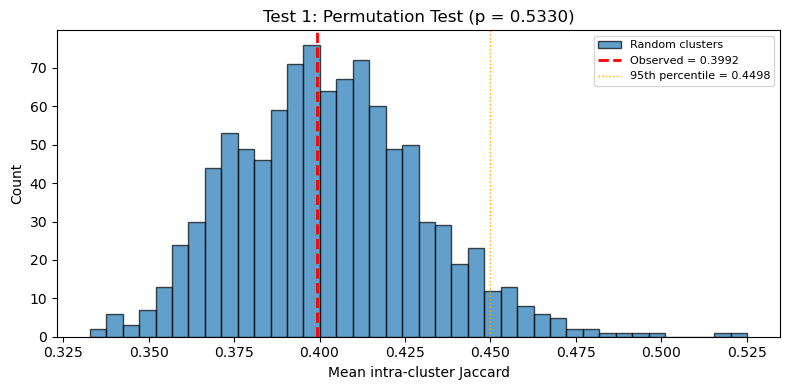

In [3]:
# Cell 3 – Test 1: Intra- vs inter-cluster similarity + permutation test
import numpy as np, matplotlib.pyplot as plt

# ── Compute full Jaccard matrix ──────────────────────────────────────────
n = len(circuit_names)
jaccard_mat = np.zeros((n, n))
for i in range(n):
    a = layer_matrix[i].astype(bool)
    for j in range(i + 1, n):
        b = layer_matrix[j].astype(bool)
        inter = (a & b).sum()
        union = (a | b).sum()
        jac = inter / union if union > 0 else 0.0
        jaccard_mat[i, j] = jaccard_mat[j, i] = jac

# ── Observed intra / inter / across means ────────────────────────────────
def cluster_means(idx_list, all_idx, mat):
    intra_vals = []
    inter_vals = []
    other = [i for i in all_idx if i not in set(idx_list)]
    for ii, i in enumerate(idx_list):
        for j in idx_list[ii+1:]:
            intra_vals.append(mat[i, j])
        for j in other:
            inter_vals.append(mat[i, j])
    return np.mean(intra_vals) if intra_vals else 0, np.mean(inter_vals) if inter_vals else 0

all_idx = list(range(n))
obs_intra, obs_inter = cluster_means(cluster_idx, all_idx, jaccard_mat)

print(f"Observed intra-cluster Jaccard : {obs_intra:.4f}")
print(f"Observed inter-cluster Jaccard : {obs_inter:.4f}")
print(f"Ratio (intra / inter)          : {obs_intra / obs_inter:.2f}x" if obs_inter > 0 else "")

# ── Permutation test ─────────────────────────────────────────────────────
np.random.seed(42)
N_PERMS = 1000
k = len(cluster_idx)
perm_intras = []

for _ in range(N_PERMS):
    fake_cluster = list(np.random.choice(n, size=k, replace=False))
    fake_intra, _ = cluster_means(fake_cluster, all_idx, jaccard_mat)
    perm_intras.append(fake_intra)

perm_intras = np.array(perm_intras)
p_value = (perm_intras >= obs_intra).mean()

print(f"\nPermutation test ({N_PERMS} iterations):")
print(f"  Random intra mean : {perm_intras.mean():.4f} +/- {perm_intras.std():.4f}")
print(f"  Observed intra    : {obs_intra:.4f}")
print(f"  p-value           : {p_value:.4f}")
print(f"  Significant (p<0.05): {'YES' if p_value < 0.05 else 'NO'}")

# ── Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm_intras, bins=40, edgecolor="black", alpha=0.7, label="Random clusters")
ax.axvline(obs_intra, color="red", linewidth=2, linestyle="--",
           label=f"Observed = {obs_intra:.4f}")
ax.axvline(np.percentile(perm_intras, 95), color="orange", linewidth=1, linestyle=":",
           label=f"95th percentile = {np.percentile(perm_intras, 95):.4f}")
ax.set_xlabel("Mean intra-cluster Jaccard")
ax.set_ylabel("Count")
ax.set_title(f"Test 1: Permutation Test (p = {p_value:.4f})")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Test 2: Shared Core Extraction

Progressively intersect circuit masks within the cluster. If a stable "iteration core" exists, the neuron count plateaus instead of dropping to zero. Done separately for AST iteration nodes and Builtin iteration functions, then their intersection gives the true iteration substrate.

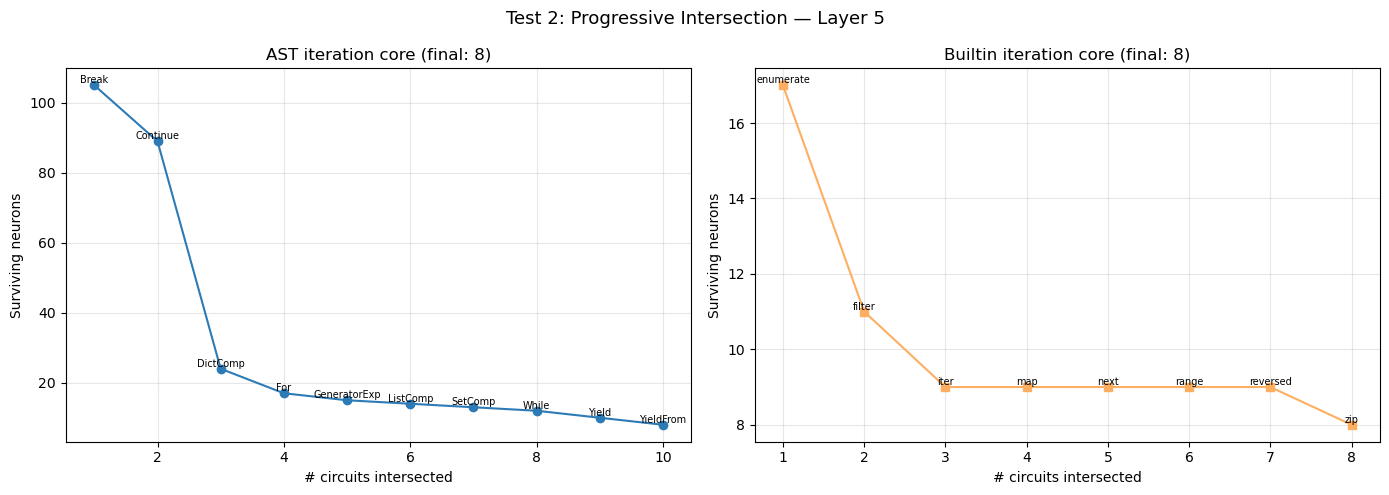


AST core       : 8 neurons
Builtin core   : 8 neurons
Combined core  : 4 neurons (AST core ∩ Builtin core)
Core neuron IDs: [990, 1529, 1822, 2028]


In [4]:
# Cell 4 – Test 2: Shared Core Extraction (progressive intersection)
import numpy as np, matplotlib.pyplot as plt

ast_cluster_idx = [i for i in cluster_idx if circuit_names[i].startswith("AST:")]
blt_cluster_idx = [i for i in cluster_idx if circuit_names[i].startswith("BLT:")]

def progressive_intersection(indices, matrix, names):
    if not indices:
        return [], [], np.array([])
    running = matrix[indices[0]].astype(bool).copy()
    labels = [names[indices[0]]]
    sizes  = [int(running.sum())]
    for idx in indices[1:]:
        running = running & matrix[idx].astype(bool)
        labels.append(names[idx])
        sizes.append(int(running.sum()))
    return labels, sizes, running

ast_labels, ast_sizes, ast_core = progressive_intersection(
    ast_cluster_idx, layer_matrix, circuit_names)
blt_labels, blt_sizes, blt_core = progressive_intersection(
    blt_cluster_idx, layer_matrix, circuit_names)

if len(ast_core) > 0 and len(blt_core) > 0:
    combined_core = ast_core & blt_core
    n_combined = int(combined_core.sum())
else:
    combined_core = np.zeros(n_sel_layer, dtype=bool)
    n_combined = 0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(range(1, len(ast_sizes)+1), ast_sizes, marker="o", color="#2c7bb6")
for i, (lbl, sz) in enumerate(zip(ast_labels, ast_sizes)):
    ax.annotate(lbl.replace("AST:", ""), (i+1, sz), fontsize=7, ha="center", va="bottom")
ax.set_xlabel("# circuits intersected"); ax.set_ylabel("Surviving neurons")
ax.set_title(f"AST iteration core (final: {ast_sizes[-1] if ast_sizes else 0})")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(range(1, len(blt_sizes)+1), blt_sizes, marker="s", color="#fdae61")
for i, (lbl, sz) in enumerate(zip(blt_labels, blt_sizes)):
    ax.annotate(lbl.replace("BLT:", ""), (i+1, sz), fontsize=7, ha="center", va="bottom")
ax.set_xlabel("# circuits intersected"); ax.set_ylabel("Surviving neurons")
ax.set_title(f"Builtin iteration core (final: {blt_sizes[-1] if blt_sizes else 0})")
ax.grid(True, alpha=0.3)

fig.suptitle(f"Test 2: Progressive Intersection — Layer {FOCUS_LAYER}", fontsize=13)
plt.tight_layout(); plt.show()

print(f"\nAST core       : {ast_sizes[-1] if ast_sizes else 0} neurons")
print(f"Builtin core   : {blt_sizes[-1] if blt_sizes else 0} neurons")
print(f"Combined core  : {n_combined} neurons (AST core ∩ Builtin core)")
if n_combined > 0:
    core_neuron_ids = layer_sel_indices[np.where(combined_core)[0]]
    print(f"Core neuron IDs: {core_neuron_ids.tolist()}")

## Test 3: Sub-cluster Structure

Split the iteration cluster into three hypothesized sub-groups and compute pairwise Jaccard within and between them:
- **Eager loops:** For, While, Break, Continue
- **Comprehensions:** ListComp, DictComp, SetComp, GeneratorExp
- **Lazy/streaming:** Yield, YieldFrom, iter, next, map, filter, zip, enumerate, range, reversed

If lazy evaluation has a specialized sub-circuit, Group C should have high internal similarity but lower similarity to Group A.

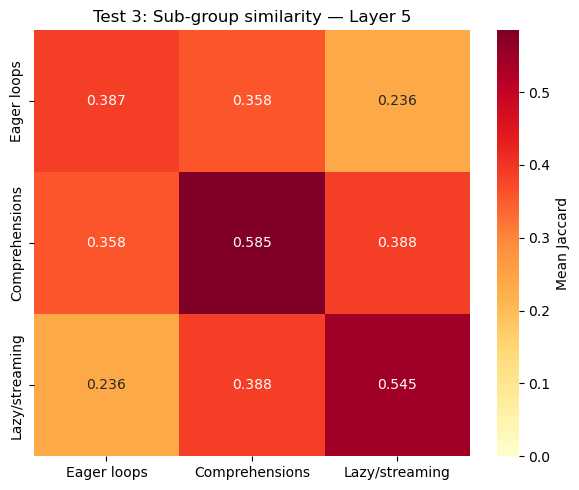

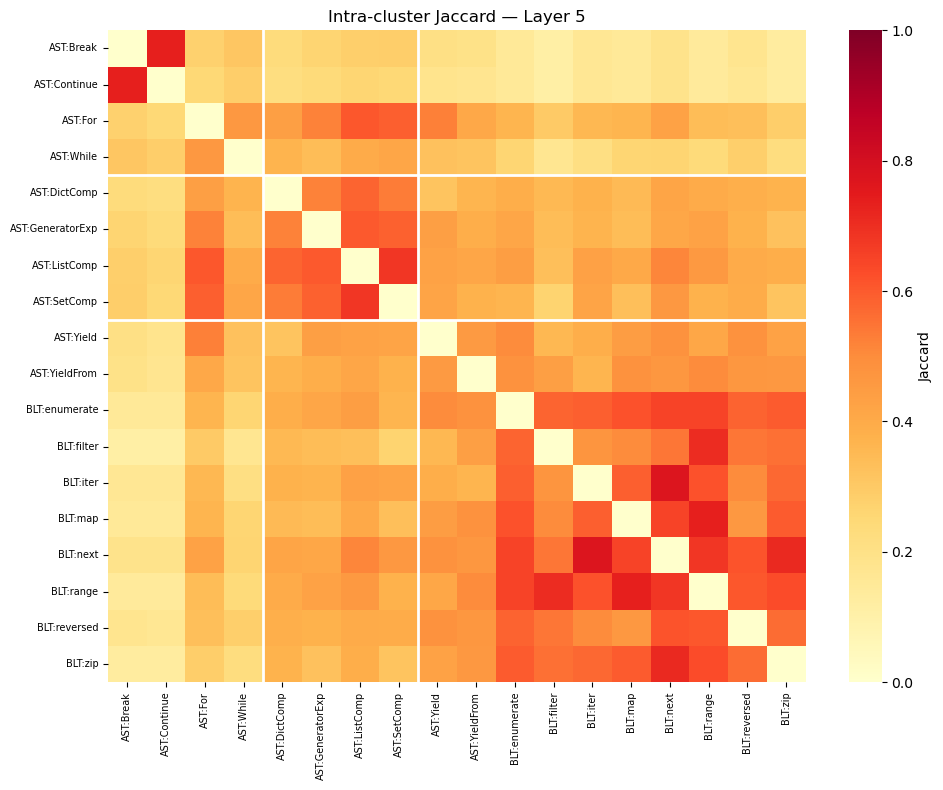

In [5]:
# Cell 5 – Test 3: Sub-cluster structure
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt

SUBGROUPS = {
    "Eager loops":     {"AST:For", "AST:While", "AST:Break", "AST:Continue"},
    "Comprehensions":  {"AST:ListComp", "AST:DictComp", "AST:SetComp", "AST:GeneratorExp"},
    "Lazy/streaming":  {"AST:Yield", "AST:YieldFrom", "BLT:iter", "BLT:next",
                        "BLT:map", "BLT:filter", "BLT:zip", "BLT:enumerate",
                        "BLT:range", "BLT:reversed"},
}

# Map circuit index → subgroup label
idx_to_group = {}
for grp, members in SUBGROUPS.items():
    for i in cluster_idx:
        if circuit_names[i] in members:
            idx_to_group[i] = grp

# Compute mean Jaccard between every pair of subgroups
group_names = list(SUBGROUPS.keys())
cross_mat = np.zeros((len(group_names), len(group_names)))

for gi, g1 in enumerate(group_names):
    idx1 = [i for i, g in idx_to_group.items() if g == g1]
    for gj, g2 in enumerate(group_names):
        idx2 = [i for i, g in idx_to_group.items() if g == g2]
        vals = []
        for i in idx1:
            for j in idx2:
                if i != j:
                    vals.append(jaccard_mat[i, j])
        cross_mat[gi, gj] = np.mean(vals) if vals else 0

# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cross_mat, ax=ax, vmin=0, annot=True, fmt=".3f", cmap="YlOrRd",
            xticklabels=group_names, yticklabels=group_names,
            cbar_kws={"label": "Mean Jaccard"})
ax.set_title(f"Test 3: Sub-group similarity — Layer {FOCUS_LAYER}")
plt.tight_layout(); plt.show()

# Detailed: pairwise Jaccard within the cluster, ordered by subgroup
ordered_idx = []
ordered_labels = []
ordered_colors = []
color_map = {"Eager loops": "#2c7bb6", "Comprehensions": "#fdae61", "Lazy/streaming": "#d7191c"}
for grp in group_names:
    for i in cluster_idx:
        if idx_to_group.get(i) == grp:
            ordered_idx.append(i)
            ordered_labels.append(circuit_names[i])
            ordered_colors.append(color_map[grp])

sub_mat = np.zeros((len(ordered_idx), len(ordered_idx)))
for ii, i in enumerate(ordered_idx):
    for jj, j in enumerate(ordered_idx):
        sub_mat[ii, jj] = jaccard_mat[i, j]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sub_mat, ax=ax, vmin=0, vmax=1, cmap="YlOrRd",
            xticklabels=ordered_labels, yticklabels=ordered_labels,
            cbar_kws={"label": "Jaccard"})
ax.set_title(f"Intra-cluster Jaccard — Layer {FOCUS_LAYER}")
ax.tick_params(labelsize=7)

# Draw sub-group boundary lines
running = 0
for grp in group_names:
    count = sum(1 for i in ordered_idx if idx_to_group.get(i) == grp)
    running += count
    if running < len(ordered_idx):
        ax.axhline(running, color="white", linewidth=2)
        ax.axvline(running, color="white", linewidth=2)

plt.tight_layout(); plt.show()

## Test 4: Core Exclusivity

How many of the iteration core neurons (from Test 2) also fire in non-iteration circuits? High exclusivity = dedicated iteration hardware. Low exclusivity = general-purpose neurons that happen to be shared.

Using: AST iteration core (8 neurons)

Core neurons          : 8
Exclusive (0 outside) : 0 (0.0%)
Shared (≥1 outside)   : 8 (100.0%)
Exclusivity score     : 0.000


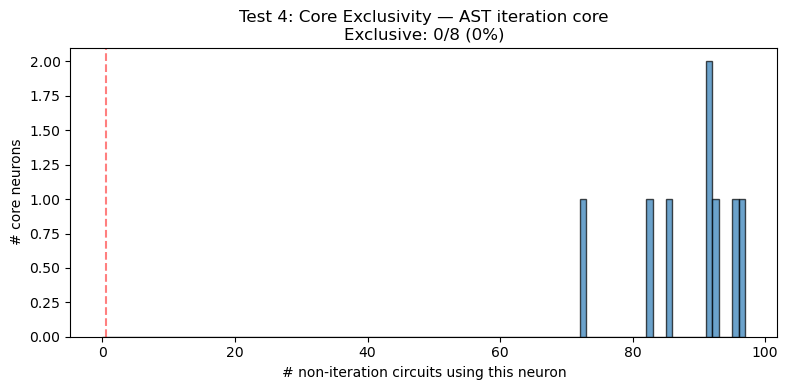


Most shared core neurons:


,neuron,n_outside_circuits
5,1659,96
6,1822,95
3,1462,92
2,1231,91
7,2028,91
4,1529,85
0,540,82
1,990,72


In [6]:
# Cell 6 – Test 4: Core Exclusivity
import numpy as np, matplotlib.pyplot as plt, pandas as pd

# Use the AST core from Test 2 (broader than combined core)
# Fall back to union of cluster masks if cores are empty
if ast_core.sum() > 0:
    test_core = ast_core
    core_label = "AST iteration core"
elif combined_core.sum() > 0:
    test_core = combined_core
    core_label = "Combined core"
else:
    # Fallback: union of all cluster circuit masks
    test_core = np.zeros(n_sel_layer, dtype=bool)
    for i in cluster_idx:
        test_core |= layer_matrix[i].astype(bool)
    core_label = "Cluster union (no intersection core survived)"

n_core = int(test_core.sum())
print(f"Using: {core_label} ({n_core} neurons)")

if n_core == 0:
    print("No core neurons to analyze.")
else:
    # For each core neuron, count how many non-iteration circuits also use it
    non_iter_matrix = layer_matrix[other_idx]
    core_neuron_positions = np.where(test_core)[0]
    
    leakage = []
    for pos in core_neuron_positions:
        n_outside = int(non_iter_matrix[:, pos].sum())
        leakage.append(n_outside)
    
    leakage = np.array(leakage)
    n_exclusive = int((leakage == 0).sum())
    n_shared    = int((leakage > 0).sum())
    exclusivity = n_exclusive / n_core
    
    print(f"\nCore neurons          : {n_core}")
    print(f"Exclusive (0 outside) : {n_exclusive} ({100*exclusivity:.1f}%)")
    print(f"Shared (≥1 outside)   : {n_shared} ({100*(1-exclusivity):.1f}%)")
    print(f"Exclusivity score     : {exclusivity:.3f}")
    
    # Distribution: how many outside circuits use each core neuron
    fig, ax = plt.subplots(figsize=(8, 4))
    max_leak = int(leakage.max())
    bins = range(0, max_leak + 2)
    ax.hist(leakage, bins=bins, edgecolor="black", alpha=0.7, color="#2c7bb6")
    ax.set_xlabel("# non-iteration circuits using this neuron")
    ax.set_ylabel("# core neurons")
    ax.set_title(f"Test 4: Core Exclusivity — {core_label}\n"
                 f"Exclusive: {n_exclusive}/{n_core} ({100*exclusivity:.0f}%)")
    ax.axvline(0.5, color="red", linestyle="--", alpha=0.5)
    plt.tight_layout(); plt.show()
    
    # Top leaked neurons — which outside circuits use them most
    if n_shared > 0:
        leak_df = pd.DataFrame({
            "neuron": layer_sel_indices[core_neuron_positions],
            "n_outside_circuits": leakage,
        }).sort_values("n_outside_circuits", ascending=False).head(15)
        print("\nMost shared core neurons:")
        display(leak_df)

## Test 5: t-SNE Projection

Project all circuit vectors (Layer 5 selective neurons) into 2D using t-SNE with precomputed Jaccard distances. Circuits are colored by membership: iteration cluster vs non-cluster, with sub-group shapes.

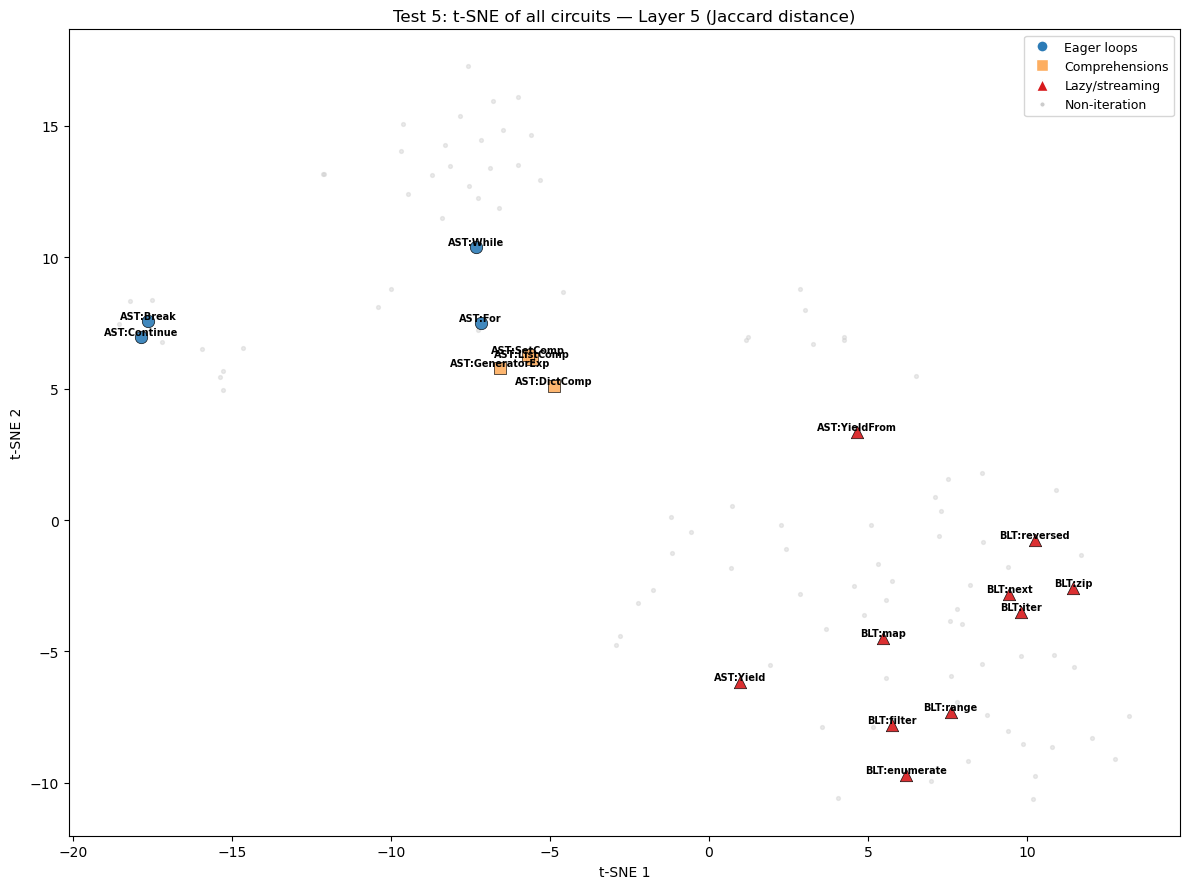

In [7]:
# Cell 7 – Test 5: t-SNE projection
from sklearn.manifold import TSNE
import numpy as np, matplotlib.pyplot as plt

# Jaccard distance matrix
jaccard_dist = 1.0 - jaccard_mat
np.fill_diagonal(jaccard_dist, 0)

tsne = TSNE(n_components=2, metric="precomputed", perplexity=min(15, n - 1),
            random_state=42, init="random")
emb = tsne.fit_transform(jaccard_dist)

# ── Assign visual properties ────────────────────────────────────────────
colors = []
markers = []
for i, cname in enumerate(circuit_names):
    if cname in SUBGROUPS.get("Eager loops", set()):
        colors.append("#2c7bb6"); markers.append("o")
    elif cname in SUBGROUPS.get("Comprehensions", set()):
        colors.append("#fdae61"); markers.append("s")
    elif cname in SUBGROUPS.get("Lazy/streaming", set()):
        colors.append("#d7191c"); markers.append("^")
    else:
        colors.append("#cccccc"); markers.append(".")

fig, ax = plt.subplots(figsize=(12, 9))

# Plot non-cluster first (background)
for i in range(n):
    if not is_cluster[i]:
        ax.scatter(emb[i, 0], emb[i, 1], c=colors[i], marker=markers[i],
                   s=30, alpha=0.4, zorder=1)

# Plot cluster circuits on top
for i in range(n):
    if is_cluster[i]:
        ax.scatter(emb[i, 0], emb[i, 1], c=colors[i], marker=markers[i],
                   s=80, alpha=0.9, edgecolors="black", linewidth=0.5, zorder=2)
        ax.annotate(circuit_names[i], (emb[i, 0], emb[i, 1]),
                    fontsize=7, ha="center", va="bottom", fontweight="bold")

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#2c7bb6",
           markersize=8, label="Eager loops"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#fdae61",
           markersize=8, label="Comprehensions"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="#d7191c",
           markersize=8, label="Lazy/streaming"),
    Line2D([0], [0], marker=".", color="w", markerfacecolor="#cccccc",
           markersize=8, label="Non-iteration"),
]
ax.legend(handles=legend_elements, fontsize=9, loc="best")
ax.set_title(f"Test 5: t-SNE of all circuits — Layer {FOCUS_LAYER} (Jaccard distance)")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
plt.tight_layout(); plt.show()

## Test 6: Hierarchical Clustering + Dendrogram

Agglomerative clustering on Jaccard distances. The dendrogram shows the exact merge order — if iteration circuits form a subtree (merge with each other before merging with outsiders), the cluster is structurally real. Iteration circuits are highlighted in color.

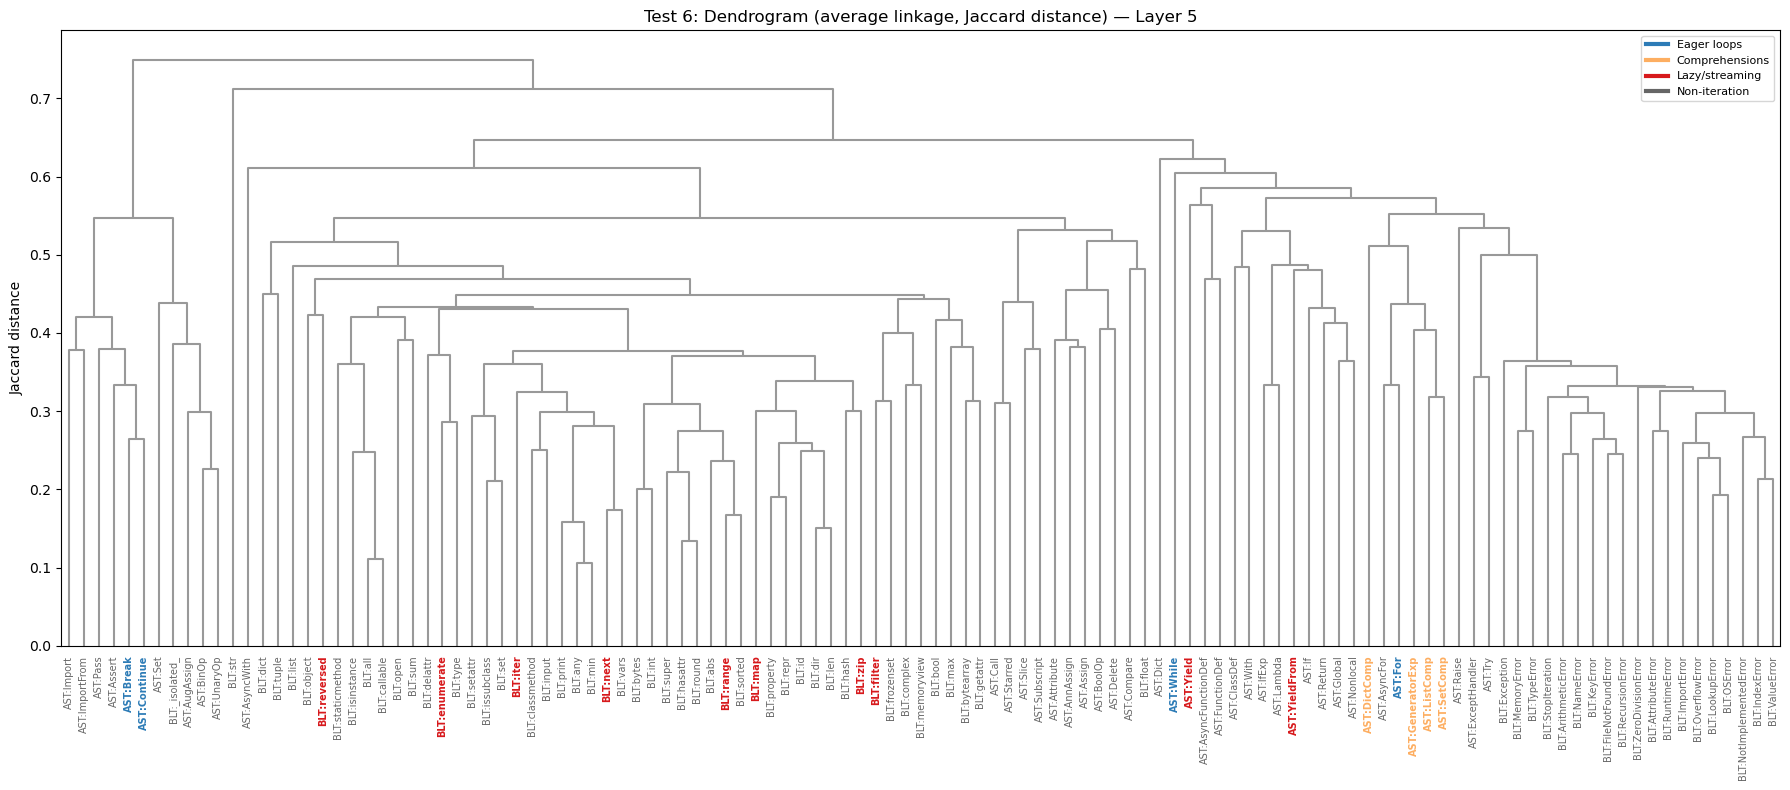

In [8]:
# Cell 8 – Test 6: Hierarchical clustering + dendrogram
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import numpy as np, matplotlib.pyplot as plt

# Convert Jaccard distance matrix to condensed form for scipy
condensed = squareform(jaccard_dist, checks=False)

# Ward-like linkage on precomputed distances — use 'average' (UPGMA)
Z = linkage(condensed, method="average")

# Color labels: iteration circuits get colored, others stay black
label_colors = {}
for i, cname in enumerate(circuit_names):
    if cname in SUBGROUPS.get("Eager loops", set()):
        label_colors[cname] = "#2c7bb6"
    elif cname in SUBGROUPS.get("Comprehensions", set()):
        label_colors[cname] = "#fdae61"
    elif cname in SUBGROUPS.get("Lazy/streaming", set()):
        label_colors[cname] = "#d7191c"
    else:
        label_colors[cname] = "#666666"

fig, ax = plt.subplots(figsize=(18, 8))
dend = dendrogram(Z, labels=circuit_names, ax=ax, leaf_rotation=90, leaf_font_size=7,
                  color_threshold=0, above_threshold_color="#999999")

# Color the x-axis labels
xlabels = ax.get_xticklabels()
for lbl in xlabels:
    txt = lbl.get_text()
    lbl.set_color(label_colors.get(txt, "#666666"))
    if txt in cluster_names:
        lbl.set_fontweight("bold")

ax.set_title(f"Test 6: Dendrogram (average linkage, Jaccard distance) — Layer {FOCUS_LAYER}")
ax.set_ylabel("Jaccard distance")

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="#2c7bb6", linewidth=3, label="Eager loops"),
    Line2D([0], [0], color="#fdae61", linewidth=3, label="Comprehensions"),
    Line2D([0], [0], color="#d7191c", linewidth=3, label="Lazy/streaming"),
    Line2D([0], [0], color="#666666", linewidth=3, label="Non-iteration"),
]
ax.legend(handles=legend_elements, fontsize=8, loc="upper right")
plt.tight_layout(); plt.show()

## Verdict

In [9]:
# Cell 9 – Verdict: summarize all test results
print("=" * 65)
print(f"ITERATION & STREAMING CLUSTER — LAYER {FOCUS_LAYER} VERDICT")
print("=" * 65)

# Test 1
print(f"\nTest 1: Intra- vs Inter-cluster Similarity")
print(f"  Intra-cluster Jaccard : {obs_intra:.4f}")
print(f"  Inter-cluster Jaccard : {obs_inter:.4f}")
print(f"  Ratio                 : {obs_intra/obs_inter:.2f}x" if obs_inter > 0 else "")
print(f"  Permutation p-value   : {p_value:.4f}")
verdict_1 = "PASS" if p_value < 0.05 else "FAIL"
print(f"  Verdict               : {verdict_1}")

# Test 2
ast_final = ast_sizes[-1] if ast_sizes else 0
blt_final = blt_sizes[-1] if blt_sizes else 0
print(f"\nTest 2: Shared Core Extraction")
print(f"  AST core              : {ast_final} neurons")
print(f"  Builtin core          : {blt_final} neurons")
print(f"  Combined core         : {n_combined} neurons")
verdict_2 = "PASS" if (ast_final > 0 or blt_final > 0) else "FAIL"
print(f"  Verdict               : {verdict_2} ({'core exists' if verdict_2 == 'PASS' else 'no stable core'})")

# Test 3
print(f"\nTest 3: Sub-cluster Structure")
for gi, g1 in enumerate(group_names):
    print(f"  {g1} self-similarity: {cross_mat[gi, gi]:.4f}")
verdict_3 = "CHECK HEATMAP"
print(f"  Verdict               : {verdict_3} (look for block-diagonal pattern)")

# Test 4
if n_core > 0:
    print(f"\nTest 4: Core Exclusivity")
    print(f"  Core neurons          : {n_core}")
    print(f"  Exclusive             : {n_exclusive} ({100*exclusivity:.0f}%)")
    print(f"  Shared                : {n_shared} ({100*(1-exclusivity):.0f}%)")
    verdict_4 = "DEDICATED" if exclusivity > 0.5 else "SUPERPOSITION"
    print(f"  Verdict               : {verdict_4}")
else:
    print(f"\nTest 4: Skipped (no core neurons)")
    verdict_4 = "N/A"

print(f"\n{'=' * 65}")
print("INTERPRETATION:")
if verdict_1 == "PASS" and verdict_2 == "PASS":
    if verdict_4 == "DEDICATED":
        print("  Strong evidence: dedicated iteration circuit exists.")
    elif verdict_4 == "SUPERPOSITION":
        print("  The cluster is real but shares neurons with other concepts")
        print("  — superposition, not full specialization.")
    else:
        print("  Cluster exists with stable core. Check exclusivity manually.")
elif verdict_1 == "PASS":
    print("  Circuits are similar but no stable intersection core.")
    print("  Suggests overlapping but not identical neural populations.")
else:
    print("  No meaningful cluster found. These circuits are NOT more similar")
    print("  to each other than to random circuits.")
print("=" * 65)

ITERATION & STREAMING CLUSTER — LAYER 5 VERDICT

Test 1: Intra- vs Inter-cluster Similarity
  Intra-cluster Jaccard : 0.3992
  Inter-cluster Jaccard : 0.3924
  Ratio                 : 1.02x
  Permutation p-value   : 0.5330
  Verdict               : FAIL

Test 2: Shared Core Extraction
  AST core              : 8 neurons
  Builtin core          : 8 neurons
  Combined core         : 4 neurons
  Verdict               : PASS (core exists)

Test 3: Sub-cluster Structure
  Eager loops self-similarity: 0.3868
  Comprehensions self-similarity: 0.5849
  Lazy/streaming self-similarity: 0.5455
  Verdict               : CHECK HEATMAP (look for block-diagonal pattern)

Test 4: Core Exclusivity
  Core neurons          : 8
  Exclusive             : 0 (0%)
  Shared                : 8 (100%)
  Verdict               : SUPERPOSITION

INTERPRETATION:
  No meaningful cluster found. These circuits are NOT more similar
  to each other than to random circuits.
